**Purpose:**  
This notebook performs statistical analyses to test whether gene expression differs among methylation types (e.g., gbM, teM, uM) across different gene duplication modes (e.g., whole-genome duplication, non-syntenic WGD, syntenic secondary duplication, tandem, proximal, transposed, dispersed).  

**Description:**  
- Loaded necessary datasets.  
- Group genes by duplication mode and methylation type.  
- Run statistical tests (Mann-Whitney test) to compare expression levels.  
- Visualize results to identify patterns of differential expression.  

**Notes:**  
- Methylation types: gbM (gene body methylation), teM (transposable element methylation), uM (unmethylated).  
 

In [269]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

## Mann-Whitney test in WGD duplicates

In [270]:
df = pd.read_csv("ActualWgd_pairs_TPM_2fold.txt", sep ='\t')
df.head()



,Gene1,Type1,TPM1,RPK1,Gene2,Type2,TPM2,RPK2
0,Leutr000g009810,um,136.170213,5.870536,Leutr021g016000,um,352.601156,15.201253
1,Leutr000g009830,um,85.774059,3.697870,Leutr021g016010,um,228.629579,9.856622
2,Leutr000g010360,um,356.982823,15.390155,Leutr021g016240,tem,3.805899,0.164079
3,Leutr000g010730,um,24.475524,1.055183,Leutr021g016810,um,11.023622,0.475248
4,Leutr000g010740,um,333.333333,14.370584,Leutr021g016820,unknown,40.983607,1.766875


In [271]:
# Select Gene1 columns
df_gene1 = df[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_gene2 = df[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate vertically
df_collapsed = pd.concat([df_gene1, df_gene2], ignore_index=True)
print(df_collapsed)

                  Gene     Type         TPM        RPK
0      Leutr000g009810       um  136.170213   5.870536
1      Leutr000g009830       um   85.774059   3.697870
2      Leutr000g010360       um  356.982823  15.390155
3      Leutr000g010730       um   24.475524   1.055183
4      Leutr000g010740       um  333.333333  14.370584
...                ...      ...         ...        ...
10425  Leutr008g021190       um  861.963190  37.160743
10426  Leutr008g007570       um   27.777778   1.197549
10427  Leutr008g022510  unknown  126.270524   5.443743
10428  Leutr008g008610       um  878.000000  37.852118
10429  Leutr008g006950       um    8.917197   0.384436

[10430 rows x 4 columns]


In [272]:
df_filtered = df_collapsed[((df_collapsed['Type'] == 'gbm'))]
                 
df_filtered.head()

,Gene,Type,TPM,RPK
30,Leutr000g032590,gbm,731.122089,31.519954
50,Leutr000g002580,gbm,1904.761905,82.117622
87,Leutr000g005680,gbm,159.322820,6.868686
108,Leutr000g006380,gbm,857.407407,36.964335
139,Leutr000g029730,gbm,79.131109,3.411481


In [273]:
df_tem = df_collapsed[((df_collapsed['Type'] == 'tem'))]
                 
df_tem.head()

,Gene,Type,TPM,RPK
18,Leutr000g010420,tem,0.799361,0.034462
198,Leutr000g024110,tem,0.303122,0.013068
481,Leutr001g033030,tem,63.025210,2.717127
530,Leutr001g035560,tem,22.912621,0.987803
689,Leutr001g038450,tem,5.479452,0.236229


In [274]:
tem_rpk = df_tem['RPK']

gbm_rpk = df_filtered['RPK']
print(f'First few rows of gbm_rpk: {gbm_rpk.head(5)}')
print(f'First few rows of tem_rpk: {tem_rpk.head(5)}')

First few rows of gbm_tpm: 30     31.519954
50     82.117622
87      6.868686
108    36.964335
139     3.411481
Name: RPK, dtype: float64
First few rows of tem_tpm: 18     0.034462
198    0.013068
481    2.717127
530    0.987803
689    0.236229
Name: RPK, dtype: float64


### Runnning Mann-Whitney in comparison of expresison between gbM and teM

In [275]:
u_stat, p_value = mannwhitneyu(gbm_rpk, tem_rpk, alternative="two-sided")
print("U =", u_stat, "p =", p_value)
if p_value < 0.05:
    print(f'P-value is significant: {p_value}')

U = 35976.0 p = 3.957077882181001e-28
P-value is significant: 3.957077882181001e-28


In [276]:
print("Median gbM RPK:", gbm_rpk.median())
print("Median teM RPK:", tem_rpk.median())

Median gbM TPM: 15.368023965595906
Median teM TPM: 2.1729713544597904


In [277]:
um_rpk = df_collapsed.loc[df_collapsed['Type'] == 'um', 'RPK']
um_rpk.head()

0     5.870536
1     3.697870
2    15.390155
3     1.055183
4    14.370584
Name: RPK, dtype: float64

### Runnning Mann-Whitney in comparison of expresison between gbM and uM

In [278]:
u_stat_gbm_um, p_value_gbm_um = mannwhitneyu(gbm_rpk, um_rpk, alternative="two-sided")
print("U =",u_stat_gbm_um, "p =", p_value_gbm_um)
if p_value_gbm_um < 0.05:
    print(f'P-value is significant: {p_value_gbm_um}')

U = 2410158.0 p = 3.922561163579783e-25
P-value is significant: 3.922561163579783e-25


### Runnning Mann-Whitney in comparison of expresison between teM and uM

In [279]:
u_stat_tem_um, p_value_tem_um = mannwhitneyu(tem_rpk, um_rpk, alternative="two-sided")
print("U =",u_stat_tem_um, "p =", p_value_tem_um)
if p_value_tem_um < 0.05:
    print(f'P-value is significant: {p_value_tem_um}')

U = 296759.5 p = 1.5302772610765073e-11
P-value is significant: 1.5302772610765073e-11


## Analysis for Synetnic Secondary Duplications

** Results**
Only methylation types gbM vs teM were statisitcally different from one another


In [280]:
df_same = pd.read_csv("sameWgd_pairs_TPM_2fold.txt", sep ='\t')
df_same.head(10)
print(df_same.columns)

# Select Gene1 columns
df_same_gene1 = df_same[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_same_gene2 = df_same[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_same_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate vertically
df_same_collapsed = pd.concat([df_same_gene1, df_same_gene2], ignore_index=True)
print(df_same_collapsed)

um_rpk_same = df_same_collapsed.loc[df_same_collapsed['Type'] == 'um', 'RPK']
um_rpk_same.head()
tem_rpk_same = df_same_collapsed.loc[df_same_collapsed['Type'] == 'tem', 'RPK']
gbm_rpk_same = df_same_collapsed.loc[df_same_collapsed['Type'] == 'gbm', 'RPK']

u_stat_gbm_tem, p_value_gbm_tem = mannwhitneyu(gbm_rpk_same, tem_rpk_same, alternative="two-sided")
print("U =",u_stat_gbm_tem, "p =", p_value_gbm_tem)
if p_value_gbm_tem < 0.05:
    print(f'P-value is significant, gbm > tem: {p_value_gbm_tem}')
u_stat_gbm_um, p_value_gbm_um = mannwhitneyu(gbm_rpk_same, um_rpk_same, alternative="two-sided")
print("U =",u_stat_gbm_um, "p =", p_value_gbm_um)
if p_value_gbm_um < 0.05:
    print(f'P-value is significant, gbm > um: {p_value_um_gbm}')
u_stat_um_tem, p_value_um_tem = mannwhitneyu(um_rpk_same, tem_rpk_same, alternative="two-sided")
print("U =",u_stat_um_tem, "p =", p_value_um_tem)
if p_value_um_tem < 0.05:
    print(f'P-value is significant, um > tem: {p_value_um_tem}')


Index(['Gene1', 'Type1', 'TPM1', 'RPK1', 'Gene2', 'Type2', 'TPM2', 'RPK2'], dtype='object')
                Gene1 Type1        TPM1       RPK1             Gene Type  \
0     Leutr000g011310    um  399.641577  17.229248              NaN  NaN   
1     Leutr000g011340    um  719.207173  31.006281              NaN  NaN   
2     Leutr000g011390    um   98.437500   4.243813              NaN  NaN   
3     Leutr000g011400    um   55.482166   2.391933              NaN  NaN   
4     Leutr000g004180    um    2.096436   0.090381              NaN  NaN   
...               ...   ...         ...        ...              ...  ...   
3101              NaN   NaN         NaN        NaN  Leutr009g018510   um   
3102              NaN   NaN         NaN        NaN  Leutr009g018490   um   
3103              NaN   NaN         NaN        NaN  Leutr009g007230   um   
3104              NaN   NaN         NaN        NaN  Leutr009g007210   um   
3105              NaN   NaN         NaN        NaN  Leutr009g007160   um

## Analysis for wgd occuring on the another chromosome other than its duplicate 

** Results**
All methylation types were statisitcally different from one another


In [281]:
df_other = pd.read_csv("otherWgd_pairs_TPM_2fold.txt", sep ='\t')

# Select Gene1 columns
df_other_gene1 = df_other[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_other_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_other_gene2 = df_other[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_other_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate them vertically
df_other_collapsed = pd.concat([df_other_gene1, df_other_gene2], ignore_index=True)
print(df_other_collapsed)

um_rpk_other = df_other_collapsed.loc[df_other_collapsed['Type'] == 'um', 'RPK']
um_rpk_other.head()
tem_rpk_other = df_other_collapsed.loc[df_other_collapsed['Type'] == 'tem', 'RPK']
gbm_rpk_other = df_other_collapsed.loc[df_other_collapsed['Type'] == 'gbm', 'RPK']

u_stat_gbm_tem_other, p_value_gbm_tem_other = mannwhitneyu(gbm_rpk_other, tem_rpk_other, alternative="two-sided")
print("U =",u_stat_gbm_tem_other, "p =", p_value_gbm_tem_other)
if p_value_gbm_tem_other < 0.05:
    print(f'P-value is significant, gbm > tem: {p_value_gbm_tem_other}')
u_stat_gbm_um_other, p_value_gbm_um_other = mannwhitneyu(gbm_rpk_other, um_rpk_other, alternative="two-sided")
print("U =",u_stat_gbm_um_other, "p =", p_value_gbm_um_other)
if p_value_gbm_um_other < 0.05:
    print(f'P-value is significant, gbm > um: {p_value_gbm_um_other}')
u_stat_um_tem_other, p_value_um_tem_other = mannwhitneyu(um_rpk_other, tem_rpk_other, alternative="two-sided")
print("U =",u_stat_um_tem_other, "p =", p_value_um_tem_other)
if p_value_um_tem_other < 0.05:
    print(f'P-value is significant, um > tem: {p_value_um_tem_other}')


                 Gene     Type         TPM        RPK
0     Leutr000g031780       um   47.707559   2.056756
1     Leutr000g013550       um   69.380204   2.991102
2     Leutr000g012630       um  120.196239   5.181870
3     Leutr000g027180  unknown  223.090278   9.617813
4     Leutr000g001720  unknown   41.533546   1.790584
...               ...      ...         ...        ...
6403  Leutr008g022510  unknown  126.270524   5.443743
6404  Leutr008g023060       um    1.036807   0.044699
6405  Leutr008g003310  unknown    1.148106   0.049497
6406  Leutr008g022310       um  140.099010   6.039914
6407  Leutr008g008910  unknown  246.284501  10.617756

[6408 rows x 4 columns]
U = 18431.0 p = 1.779271288666922e-19
P-value is significant, gbm > tem: 1.779271288666922e-19
U = 1020313.0 p = 3.4862014242126654e-15
P-value is significant, gbm > um: 3.4862014242126654e-15
U = 290023.5 p = 1.0471926651751924e-08
P-value is significant, um > tem: 1.0471926651751924e-08


## Analysis for Dispersed duplicates

Results: **
All methylation types were statisitcally different from one another


In [282]:
df_dis = pd.read_csv("dispersed_pairs_TPM_2fold.txt", sep ='\t')

# Select Gene1 columns
df_dis_gene1 = df_dis[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_dis_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_dis_gene2 = df_dis[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_dis_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate vertically
df_dis_collapsed = pd.concat([df_dis_gene1, df_dis_gene2], ignore_index=True)
print(df_dis_collapsed)

um_rpk_dis = df_dis_collapsed.loc[df_dis_collapsed['Type'] == 'um', 'RPK']
um_rpk_dis.head()
tem_rpk_dis = df_dis_collapsed.loc[df_dis_collapsed['Type'] == 'tem', 'RPK']
gbm_rpk_dis = df_dis_collapsed.loc[df_dis_collapsed['Type'] == 'gbm', 'RPK']

u_stat_gbm_tem_dis, p_value_gbm_tem_dis = mannwhitneyu(gbm_rpk_dis, tem_rpk_dis, alternative="two-sided")
print("U =",u_stat_gbm_tem_dis, "p =", p_value_gbm_tem_dis)
if p_value_gbm_tem_dis < 0.05:
    print(f'P-value is significant, gbm > tem: {p_value_gbm_tem_dis}')
u_stat_gbm_um_dis, p_value_gbm_um_dis = mannwhitneyu(gbm_rpk_dis, um_rpk_dis, alternative="two-sided")
print("U =",u_stat_gbm_um_dis, "p =", p_value_gbm_um_dis)
if p_value_gbm_um_dis < 0.05:
    print(f'P-value is significant, gbm > um: {p_value_gbm_um_dis}')
u_stat_um_tem_dis, p_value_um_tem_dis = mannwhitneyu(um_rpk_dis, tem_rpk_dis, alternative="two-sided")
print("U =",u_stat_um_tem_dis, "p =", p_value_um_tem_dis)
if p_value_um_tem_dis < 0.05:
    print(f'P-value is significant, um > tem: {p_value_um_tem_dis}')


                  Gene     Type          TPM        RPK
0      Leutr000g000500       um   302.454473  13.039342
1      Leutr000g000520  unknown   179.681078   7.746366
2      Leutr000g000530       um    81.521739   3.514545
3      Leutr000g000540       um   654.611212  28.221436
4      Leutr000g000550       um    72.930355   3.144155
...                ...      ...          ...        ...
43545  Leutr026g014250  unknown     4.629630   0.199591
43546  Leutr017g006860      gbm   249.753208  10.767298
43547  Leutr005g000960       um  1043.194784  44.973954
43548  Leutr006g002230       um  1791.381669  77.229602
43549  Leutr006g002290       um   102.528090   4.420166

[43550 rows x 4 columns]
U = 1849425.0 p = 2.699642345262809e-257
P-value is significant, gbm > tem: 2.699642345262809e-257
U = 42558969.0 p = 1.3004813095497969e-129
P-value is significant, gbm > um: 1.3004813095497969e-129
U = 26431305.5 p = 8.019903431209686e-145
P-value is significant, um > tem: 8.019903431209686e-145


## Analysis for Proximal duplicates

** Results: **
All methylation types were statisitcally different from one another


In [283]:
df_prx = pd.read_csv("proximal_pairs_TPM_2fold.txt", sep ='\t')

# Select Gene1 columns
df_prx_gene1 = df_prx[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_prx_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_prx_gene2 = df_prx[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_prx_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate them vertically
df_prx_collapsed = pd.concat([df_prx_gene1, df_prx_gene2], ignore_index=True)
print(df_prx_collapsed)

um_rpk_prx = df_prx_collapsed.loc[df_prx_collapsed['Type'] == 'um', 'RPK']
um_rpk_prx.head()
tem_rpk_prx = df_prx_collapsed.loc[df_prx_collapsed['Type'] == 'tem', 'RPK']
gbm_rpk_prx = df_prx_collapsed.loc[df_prx_collapsed['Type'] == 'gbm', 'RPK']

u_stat_gbm_tem_prx, p_value_gbm_tem_prx = mannwhitneyu(gbm_rpk_prx, tem_rpk_prx, alternative="two-sided")
print("U =",u_stat_gbm_tem_prx, "p =", p_value_gbm_tem_prx)
if p_value_gbm_tem_prx < 0.05:
    print(f'P-value is significant, gbm > tem: {p_value_gbm_tem_prx}')
u_stat_gbm_um_prx, p_value_gbm_um_prx = mannwhitneyu(gbm_rpk_prx, um_rpk_prx, alternative="two-sided")
print("U =",u_stat_gbm_um_prx, "p =", p_value_gbm_um_prx)
if p_value_gbm_um_prx < 0.05:
    print(f'P-value is significant, gbm > um: {p_value_gbm_um_prx}')
u_stat_um_tem_prx, p_value_um_tem_prx = mannwhitneyu(um_rpk_prx, tem_rpk_prx, alternative="two-sided")
print("U =",u_stat_um_tem_prx, "p =", p_value_um_tem_prx)
if p_value_um_tem_prx < 0.05:
    print(f'P-value is significant, um > tem: {p_value_um_tem_prx}')


                 Gene     Type          TPM        RPK
0     Leutr000g001200  unknown     0.684932   0.029529
1     Leutr000g001520       um    26.923077   1.160701
2     Leutr000g001530       um    80.769231   3.482103
3     Leutr000g001630       um  1197.154472  51.611426
4     Leutr000g001650       um    87.991718   3.793477
...               ...      ...          ...        ...
4095  Leutr027g024100       um    26.020961   1.121809
4096  Leutr027g024410  unknown    60.834299   2.622673
4097  Leutr027g024420       um   411.642412  17.746625
4098  Leutr027g024470       um    24.210526   1.043758
4099  Leutr027g024860       um    90.909091   3.919250

[4100 rows x 4 columns]
U = 9318.0 p = 1.3399720002887598e-13
P-value is significant, gbm > tem: 1.3399720002887598e-13
U = 122816.5 p = 1.133927018632547e-06
P-value is significant, gbm > um: 1.133927018632547e-06
U = 254640.0 p = 1.1410664772966936e-08
P-value is significant, um > tem: 1.1410664772966936e-08


## Analysis for Tandem duplicates

Results:
Some methylation types were statisitcally different from one another
- gbM vs teM < 0.05
- gbM vs uM < 0.05

In [284]:
df_tan = pd.read_csv("tandem_pairs_TPM_2fold.txt", sep ='\t')

# Select Gene1 columns
df_tan_gene1 = df_tan[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_tan_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_tan_gene2 = df_tan[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_tan_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate vertically
df_tan_collapsed = pd.concat([df_tan_gene1, df_tan_gene2], ignore_index=True)
print(df_tan_collapsed)

um_rpk_tan = df_tan_collapsed.loc[df_tan_collapsed['Type'] == 'um', 'RPK']
um_rpk_tan.head()
tem_rpk_tan = df_tan_collapsed.loc[df_tan_collapsed['Type'] == 'tem', 'RPK']
gbm_rpk_tan = df_tan_collapsed.loc[df_tan_collapsed['Type'] == 'gbm', 'RPK']


u_stat_gbm_tem_tan, p_value_gbm_tem_tan = mannwhitneyu(gbm_rpk_tan, tem_rpk_tan, alternative="two-sided")
print("U =",u_stat_gbm_tem_tan, "p =", p_value_gbm_tem_tan)
if p_value_gbm_tem_tan < 0.05:
    print(f'P-value is significant, gbm > tem: {p_value_gbm_tem_tan}')
u_stat_gbm_um_tan, p_value_gbm_um_tan = mannwhitneyu(gbm_rpk_tan, um_rpk_tan, alternative="two-sided")
print("U =",u_stat_gbm_um_tan, "p =", p_value_gbm_um_tan)
if p_value_gbm_um_tan < 0.05:
    print(f'P-value is significant, gbm > um: {p_value_gbm_um_tan}')
u_stat_um_tem_tan, p_value_um_tem_tan = mannwhitneyu(um_rpk_tan, tem_rpk_tan, alternative="two-sided")
print("U =",u_stat_um_tem_tan, "p =", p_value_um_tem_tan)
if p_value_um_tem_tan < 0.05:
    print(f'P-value is significant, um > tem: {p_value_um_tem_tan}')


                 Gene     Type         TPM        RPK
0     Leutr000g000550       um   72.930355   3.144155
1     Leutr000g001520       um   26.923077   1.160701
2     Leutr000g001570       um  538.181818  23.201961
3     Leutr000g002390       um   46.992481   2.025928
4     Leutr000g003910       um   81.300813   3.505020
...               ...      ...         ...        ...
1289  Leutr027g020160       um  153.948242   6.636978
1290  Leutr027g020360       um   26.190476   1.129117
1291  Leutr027g020370       um   74.160646   3.197195
1292  Leutr027g021800  unknown    6.116208   0.263680
1293  Leutr027g022650       um   47.038328   2.027905

[1294 rows x 4 columns]
U = 453.0 p = 0.0021035583511790096
P-value is significant, gbm > tem: 0.0021035583511790096
U = 20520.0 p = 8.129293991852034e-07
P-value is significant, gbm > um: 8.129293991852034e-07
U = 10497.5 p = 0.43847435344825525


## Analysis for Transposed duplicates

Results: 
All methylation types were statisitcally different from one another


In [285]:
df_trans = pd.read_csv("transposed_pairs_TPM_2fold.txt", sep ='\t')

# Select Gene1 columns
df_trans_gene1 = df_trans[['Gene1', 'Type1', 'TPM1', 'RPK1']].copy()
df_trans_gene1.columns = ['Gene', 'Type', 'TPM', 'RPK']  

# Select Gene2 columns
df_trans_gene2 = df_trans[['Gene2', 'Type2', 'TPM2', 'RPK2']].copy()
df_trans_gene2.columns = ['Gene', 'Type', 'TPM', 'RPK']

# Concatenate vertically
df_trans_collapsed = pd.concat([df_trans_gene1, df_trans_gene2], ignore_index=True)
print(df_trans_collapsed)

um_rpk_trans = df_trans_collapsed.loc[df_trans_collapsed['Type'] == 'um', 'TPM']
um_rpk_trans.head()
tem_rpk_trans = df_trans_collapsed.loc[df_trans_collapsed['Type'] == 'tem', 'TPM']
gbm_rpk_trans = df_trans_collapsed.loc[df_trans_collapsed['Type'] == 'gbm', 'TPM']

u_stat_gbm_tem_trans, p_value_gbm_tem_trans = mannwhitneyu(gbm_rpk_trans, tem_rpk_trans, alternative="two-sided")
print("U =",u_stat_gbm_tem_trans, "p =", p_value_gbm_tem_trans)
if p_value_gbm_tem_trans < 0.05:
    print(f'P-value is significant, gbm > tem: {p_value_gbm_tem_trans}')
u_stat_gbm_um_trans, p_value_gbm_um_trans = mannwhitneyu(gbm_rpk_trans, um_rpk_trans, alternative="two-sided")
print("U =",u_stat_gbm_um_trans, "p =", p_value_gbm_um_trans)
if p_value_gbm_um_trans < 0.05:
    print(f'P-value is significant, gbm > um: {p_value_gbm_um_trans}')
u_stat_um_tem_trans, p_value_um_tem_trans = mannwhitneyu(um_rpk_trans, tem_rpk_trans, alternative="two-sided")
print("U =",u_stat_um_tem_trans, "p =", p_value_um_tem_trans)
if p_value_um_tem_trans < 0.05:
    print(f'P-value is significant, um > tem: {p_value_um_tem_trans}')


                 Gene     Type         TPM        RPK
0     Leutr000g000640       um  247.068677  10.651563
1     Leutr000g000650       um   68.983957   2.974019
2     Leutr000g000840       um   14.778325   0.637119
3     Leutr000g001140      tem    5.244755   0.226111
4     Leutr000g002500  unknown    8.720930   0.375975
...               ...      ...         ...        ...
6159  Leutr027g023820       um  414.610069  17.874566
6160  Leutr027g023830  unknown  257.053292  11.082018
6161  Leutr008g025250       um  420.566908  18.131376
6162  Leutr005g002120       um  655.502392  28.259856
6163  Leutr026g015710       um  338.957055  14.613032

[6164 rows x 4 columns]
U = 94577.0 p = 1.581554526091049e-60
P-value is significant, gbm > tem: 1.581554526091049e-60
U = 847064.0 p = 6.374911462407562e-18
P-value is significant, gbm > um: 6.374911462407562e-18
U = 1231664.0 p = 1.4623618759016615e-54
P-value is significant, um > tem: 1.4623618759016615e-54


## Graphs to display results from Mann-Whitney Test

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Assigning the duplication categories to create master file
df['Duplication'] = 'wgd_actual'
df_same['Duplication'] = 'wgd_same'
df_other['Duplication'] = 'wgd_other'
df_dis['Duplication'] = 'dispersed'
df_tan['Duplication'] = 'tandem'
df_prx['Duplication'] = 'proximal'
df_trans['Duplication'] = 'transposed'

# Reshaping
def reshape_pairs(df):
    df1 = df[['Gene1', 'Type1', 'RPK1', 'Duplication']].copy()
    df1.columns = ['Gene', 'Type', 'RPK', 'Duplication']

    df2 = df[['Gene2', 'Type2', 'RPK2', 'Duplication']].copy()
    df2.columns = ['Gene', 'Type', 'RPK', 'Duplication']

    return pd.concat([df1, df2], ignore_index=True)

df = reshape_pairs(df)
df_same = reshape_pairs(df_same)
df_other = reshape_pairs(df_other)
df_dis = reshape_pairs(df_dis)
df_tan = reshape_pairs(df_tan)
df_prx = reshape_pairs(df_prx)
df_trans = reshape_pairs(df_trans)

# Creating masterfile
df_all = pd.concat([
    df,
    df_same,
    df_other,
    df_dis,
    df_tan,
    df_prx,
    df_trans
], ignore_index=True)

df_all['Type'] = df_all['Type'].str.lower()
df_all['Duplication'] = df_all['Duplication'].str.lower()

#Remove unknown methylation type
df_all = df_all[df_all['Type'].isin(['gbm', 'tem', 'um'])]

# Log transform + 1 on RPK
df_all['logRPK'] = np.log10(df_all['RPK'] + 1)



## Graph for WGD 

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/1504466860.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


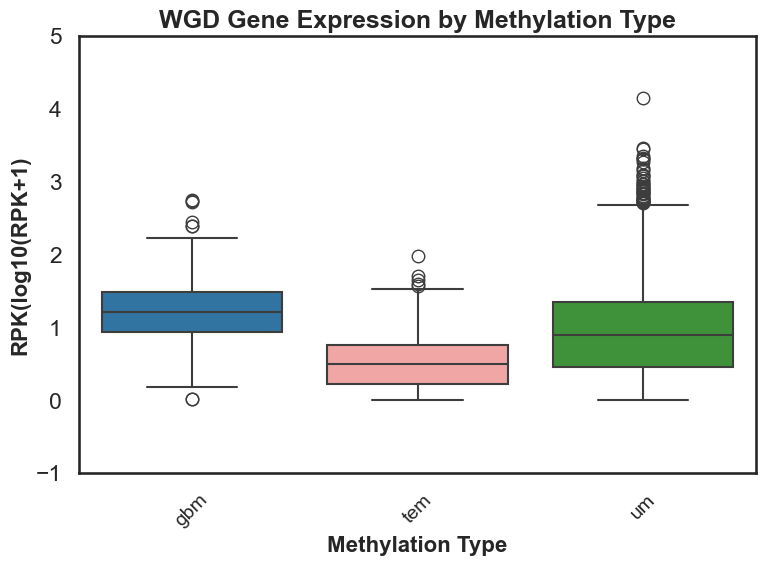

<Figure size 640x480 with 0 Axes>

In [321]:
# Subset actual WGD
subset_wgd = df_all[df_all['Duplication'] == 'wgd_actual'].copy()

subset_wgd['Type'] = subset_wgd['Type'].astype(str)

palette = sns.color_palette("Paired", 10)

custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}

# Plot
sns.set(style="white", context="talk")
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=subset_wgd,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("WGD Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(-1, 5)
plt.tight_layout()
plt.show()
plt.savefig("wgd_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Graph for Syntenic-Secondary Duplication

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/4182096364.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


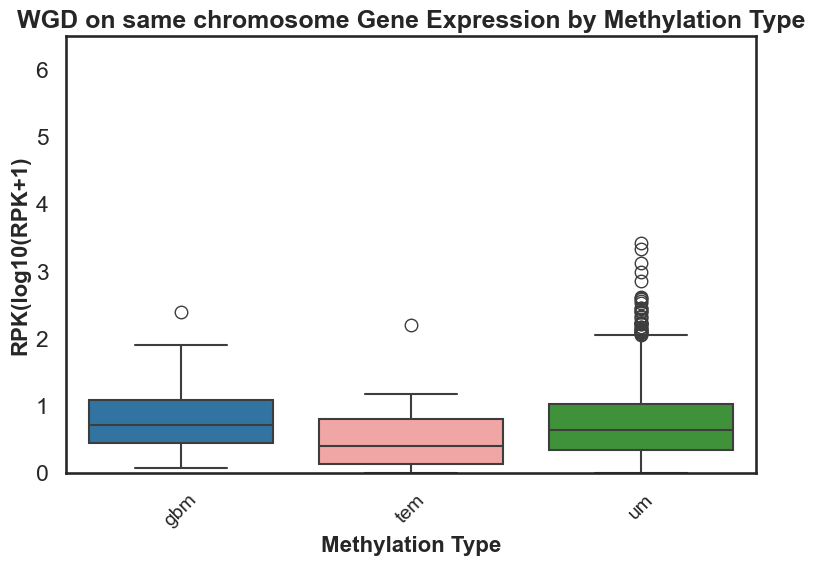

In [324]:
# Subset for syntenic-secondary duplications
subset_wgd = df_all[df_all['Duplication'] == 'wgd_same'].copy()
subset_wgd['Type'] = subset_wgd['Type'].astype(str)
palette = sns.color_palette("Paired", 10)

custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}

# Plot
sns.set(style="white", context="talk")
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=subset_wgd,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("WGD on same chromosome Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(0, 6.5)
plt.tight_layout()
plt.savefig("sameChrwgd_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Graph for other WGD

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/358413838.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


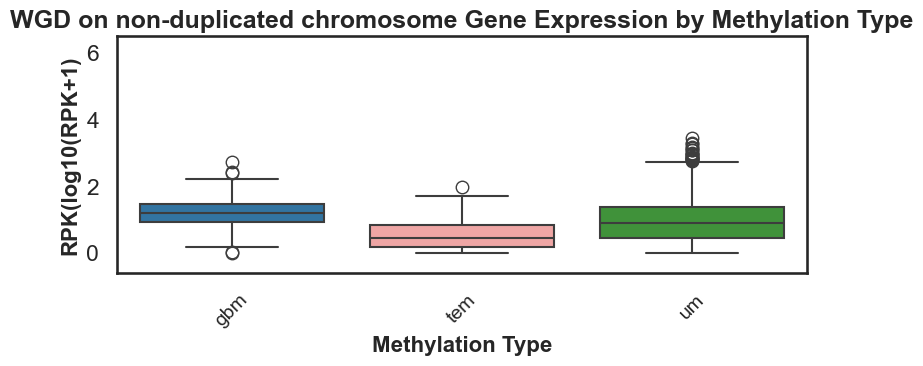

In [334]:
# Subset actual WGD
subset= df_all[df_all['Duplication'] == 'wgd_other'].copy()
subset['Type'] = subset['Type'].astype(str)
palette = sns.color_palette("Paired", 10)

custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}

# Plot
sns.set(style="white", context="talk")
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=subset,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("WGD on non-duplicated chromosome Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(-0.60, 6.5)
plt.tight_layout()
plt.savefig("otherChrwgd_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Graph on Dispersed Duplicates

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/520941677.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


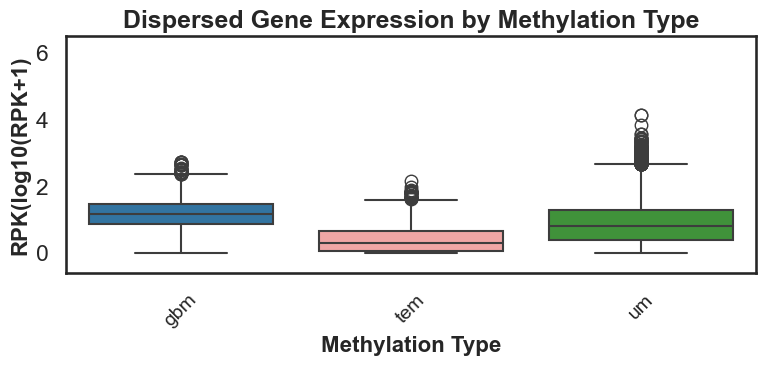

In [335]:
# Subset for dispersed
subset_dis = df_all[df_all['Duplication'] == 'dispersed'].copy()
subset_dis['Type'] = subset_dis['Type'].astype(str)
palette = sns.color_palette("Paired", 10)
custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}

# Plot
sns.set(style="white", context="talk")
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=subset_dis,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("Dispersed Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(-0.60, 6.5)
plt.tight_layout()
plt.savefig("disp_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Graph for Tandem Duplicates

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/3678471851.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


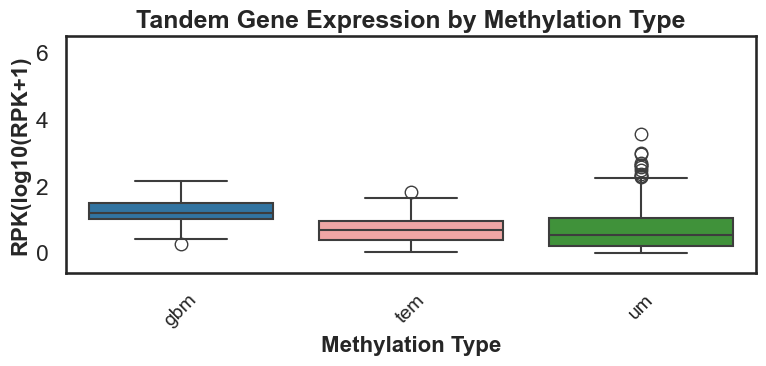

In [336]:
# Subset for tandem
subset_tan = df_all[df_all['Duplication'] == 'tandem'].copy()
subset_tan['Type'] = subset_tan['Type'].astype(str)
palette = sns.color_palette("Paired", 10)

custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}

# Plot
sns.set(style="white",context="talk")

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=subset_tan,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("Tandem Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(-0.60, 6.5)
plt.tight_layout()
plt.savefig("tan_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Graph for Proximal Duplicates

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/1670008012.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


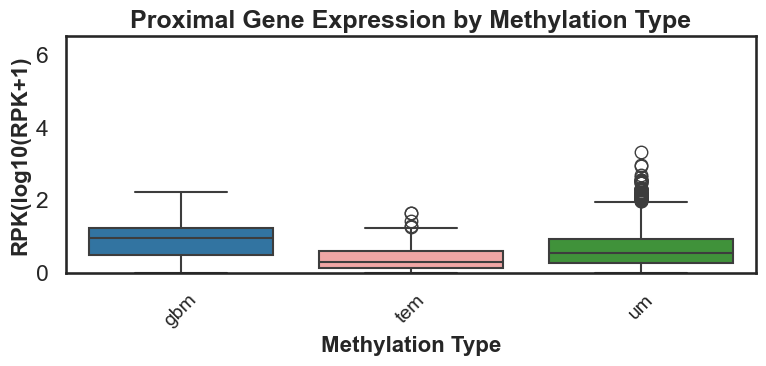

In [337]:
# Subset for proximal
subset_prx = df_all[df_all['Duplication'] == 'proximal'].copy()
subset_prx['Type'] = subset_prx['Type'].astype(str)
palette = sns.color_palette("Paired", 10)

custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}
sns.set(style="white", context="talk")

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=subset_prx,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("Proximal Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16)
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(0, 6.5)
plt.tight_layout()
plt.savefig("prx_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## Graph for Transposed duplicates

/var/folders/57/xh601pb55k13yy0r6glln07r0000gn/T/ipykernel_12792/1486271998.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


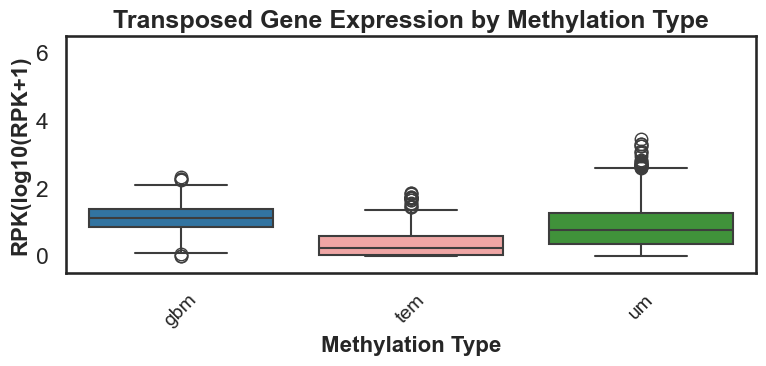

In [338]:
# Subset for proximal duplicates
subset_trn = df_all[df_all['Duplication'] == 'transposed'].copy()
subset_trn['Type'] = subset_trn['Type'].astype(str)
palette = sns.color_palette("Paired", 10)

custom_palette = {
    'gbm': palette[1],
    'tem': palette[4],
    'um':  palette[3]
}

# Plot
sns.set(style="white", context="talk")

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=subset_trn,
    x='Type',
    y='logRPK',
    order=['gbm', 'tem', 'um'],
    palette=custom_palette,
    linewidth=1.5
)

plt.title("Transposed Gene Expression by Methylation Type", fontweight = "bold", fontsize = 18)
plt.xlabel("Methylation Type", fontweight = "bold", fontsize = 16)
plt.ylabel("RPK(log10(RPK+1)", fontweight = "bold", fontsize = 16) #(log10(RPK + 1))
plt.xticks(rotation=45, fontsize = 14)
plt.ylim(-0.50, 6.5)
plt.tight_layout()
plt.savefig("trans_expression_violin_plot.png", dpi=300, bbox_inches='tight')
plt.show()